# Director Skill Sets Table 7 - Cessation only

In [1]:
import pandas_datareader.data as web #to collect data
import datetime as dt #to specify start and end dates

# import yfinance as yf

import eventstudy as es
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d
%matplotlib inline
import seaborn as sns

import scipy.stats as stats
from scipy.stats.mstats import winsorize
from scipy.spatial.distance import cdist


from sklearn.neighbors import NearestNeighbors

import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

from sklearn.preprocessing import StandardScaler

from patsy import dmatrices
from tqdm.notebook import tqdm
tqdm.pandas()

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_output4"
output_folder_path = "analysis_outputs"
# pca_input_folder_path = rf"..\..\..\[IN USE] Rookie Directors\[1.5] Director Skills PCA\director_skills_pca"
firm_input_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[2] Firm Level Wrangling\Firm level Iterative\Firm Lev + Fin\City level\city_lev_output"
filtering_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_filtering"
supporting_folder_path = "supporting_datafiles"

In [3]:
dirFirm00 = pd.read_pickle(rf"{import_folder_path}\Director Level_FF3_CAR.pkl")
dirFirm00 = dirFirm00.loc[ dirFirm00["date_source"] == "Cessation Date"].reset_index(drop = True)

# pca = pd.read_pickle(rf"{pca_input_folder_path}\Main_Director_COMPLETE_PCA.pkl")
firm = pd.read_pickle(rf"{firm_input_folder_path}\Main_Firm_COMPLETE.pkl")

In [4]:
# pca_col = [
#     "Person Code", "AsOnDate", "Symbol",
#     "SkillsetIndex", "SkillsetGeneralistDummy",
#     "PC1_FactorScore", "PC1_FactorScore_Standardised"
# ]

# pca2 = pca[pca_col].copy()
# dirFirm00 = dirFirm0.merge(pca2, on = ["Person Code", "AsOnDate", "Symbol"], how = "left")

In [5]:
firm_col = [
    "AsOnDate", "Symbol",

    "PercentWomenDir", "PercentBusyDir",
    "LnBoardSize", "PercentIndep",
    "Promoters_percent", "NonpromoterInstitutions_percent", "RD to Assets",
    "ln_marcap", "ln_rdtoassets", "Debt to equity ratio", # control variables
    
    "FamilyOwnedFamilyCeoChair25", "promoterholding25", "HasFamilyChairmanAndCEO",
]

firm2 = firm[firm_col].copy()
dirFirm = dirFirm00.merge(firm2, on = ["AsOnDate", "Symbol"], how = "left")

In [6]:
# dirFirm data wrangling if any:
dirFirm["Year of Study"] = [x.year for x in dirFirm["Date of Study"]]

dirFirm = dirFirm.drop_duplicates(subset = ["Person Code", "Company", "Date of Study"]).reset_index(drop = True)

dirFirm["ln_dirage"] = np.log(dirFirm["Age"] + 1).astype("float")
dirFirm["ln_directorships"] = np.log((dirFirm["CompCountCurrTotalAB"] - 1) + 1).astype("float")

In [7]:
dirFirm.replace([np.inf, -np.inf], pd.NA, inplace = True)

# PSM

## Verifying and removing those rows with no control data points

In [8]:
# Sample constraints ---> govtdummy==0 & findummy==0 & asonyear>2012
# dirFirm.columns.to_list()

In [9]:
dirFirm["IsDualityChairmanMD"] = dirFirm["IsDualityChairmanMD"].astype(int)


dirFirm["NIC_1digit"] = dirFirm["NIC code"].dropna().apply(lambda x: x[0:1])
dirFirm["NIC_1digit"] = dirFirm["NIC_1digit"]

dirFirm.loc[dirFirm["RD to Assets"] == 0, "ln_rdtoassets"] = 0

psmSample = dirFirm.loc[ (dirFirm["Year of Study"] >= 2013) 
    & (dirFirm["govtdummy"] == 0) & (dirFirm["findummy"] == 0) ].copy()
#.dropna(subset = controlVars).dropna(subset = dependentVar).copy()

# psmSample["DummySum"] = psmSample["IsRookie"] + psmSample["IsNonRookie"]
psmSample["DummySumIndep"] = psmSample["IsRookieIndep"] + psmSample["IsNonRookieIndep"]

# psmSampleAll = psmSample.loc[ psmSample["DummySum"] == 1 ].reset_index(drop = True)
# psmSampleAll = psmSampleAll.loc[ ~psmSampleAll.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

psmSampleIndep = psmSample.loc[ psmSample["DummySumIndep"] == 1 ].reset_index(drop = True)
# psmSampleIndep = psmSampleIndep.loc[ ~psmSampleIndep.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

## CAR windsorization

       winsorised_120CAR3  nonwinsorised_120CAR3
count         6356.000000            6356.000000
mean             0.027063               0.025121
std              2.160834               2.161109
min             -0.129012              -1.037300
25%             -0.037084              -0.037084
50%             -0.005059              -0.005059
75%              0.030134               0.030134
max            172.195616             172.195616


Top values and their count:  nonwinsorised_120CAR3
0.347761      2
0.356171      1
0.367948      1
0.431175      1
0.477541      1
0.486351      2
0.533764      1
0.554026      1
0.586782      1
172.195616    1
Name: count, dtype: int64





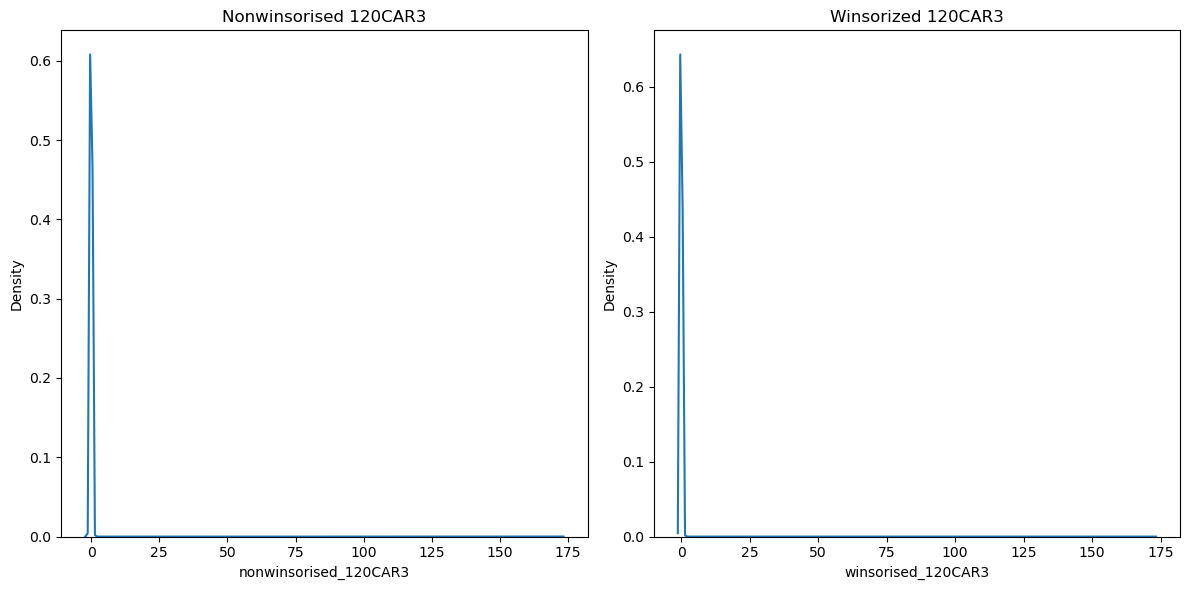

       winsorised_120CAR5  nonwinsorised_120CAR5
count         6356.000000            6356.000000
mean            -0.022364              -0.025005
std              2.161905               2.162366
min             -0.216180              -1.462671
25%             -0.096319              -0.096319
50%             -0.053835              -0.053835
75%             -0.013737              -0.013737
max            172.160588             172.160588


Top values and their count:  nonwinsorised_120CAR5
0.509280      1
0.532473      2
0.535876      1
0.594632      1
0.624013      1
0.722034      2
0.845454      1
0.851770      1
1.445203      2
172.160588    1
Name: count, dtype: int64





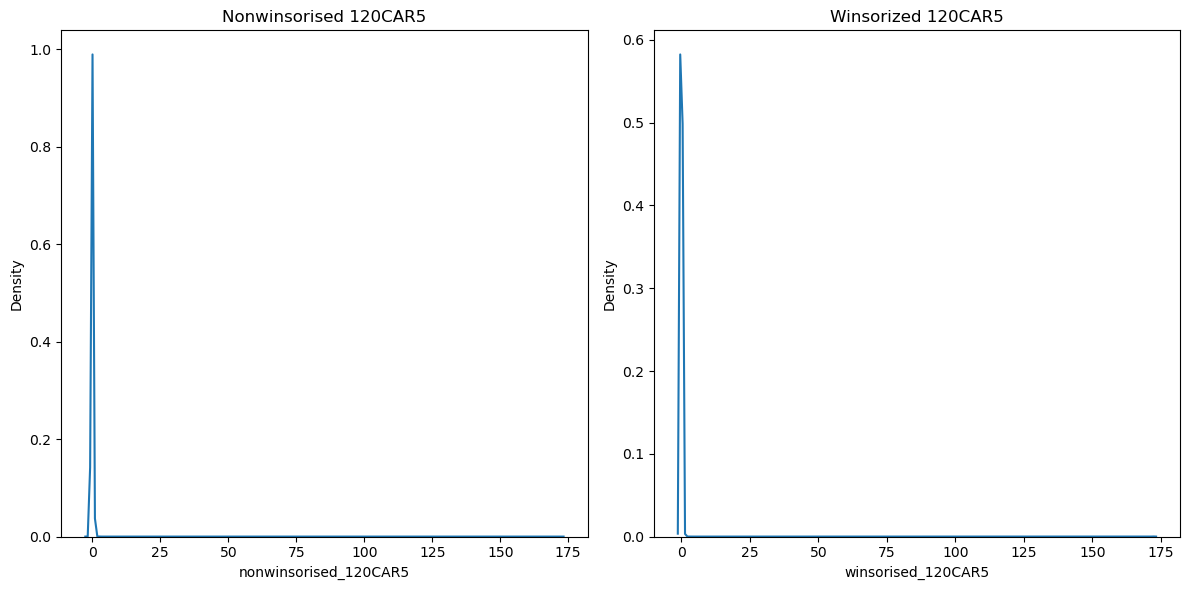

       winsorised_120CAR7  nonwinsorised_120CAR7
count         6353.000000            6353.000000
mean            -0.070733              -0.073595
std              2.163649               2.164193
min             -0.299093              -1.847159
25%             -0.157430              -0.157430
50%             -0.103920              -0.103920
75%             -0.052144              -0.052144
max            172.142157             172.142157


Top values and their count:  nonwinsorised_120CAR7
0.537508      1
0.582257      2
0.610291      1
0.628942      1
0.706554      1
0.878482      2
1.018668      2
1.338337      1
1.637965      1
172.142157    1
Name: count, dtype: int64





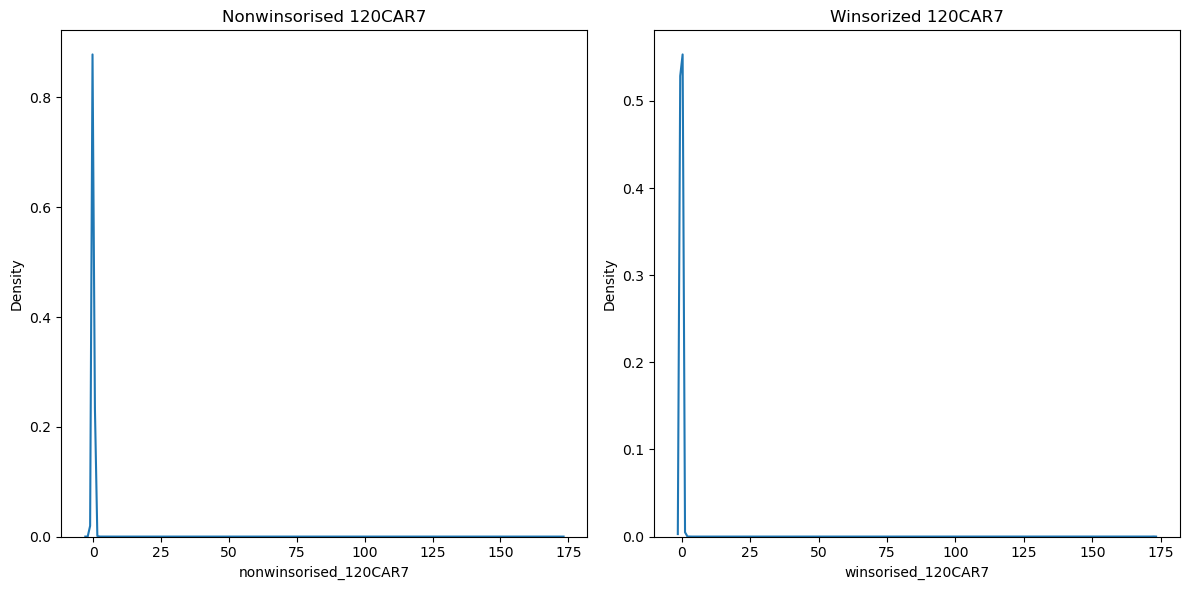

       winsorised_120CAR11  nonwinsorised_120CAR11
count          6352.000000             6352.000000
mean             -0.166993               -0.171069
std               2.166893                2.168001
min              -0.459204               -2.979978
25%              -0.275047               -0.275047
50%              -0.206171               -0.206171
75%              -0.130821               -0.130821
max             172.003758              172.003758


Top values and their count:  nonwinsorised_120CAR11
0.669056      1
0.731454      1
0.938677      2
0.959785      1
1.158457      1
1.224999      1
2.020538      1
2.313105      2
5.841753      1
172.003758    1
Name: count, dtype: int64





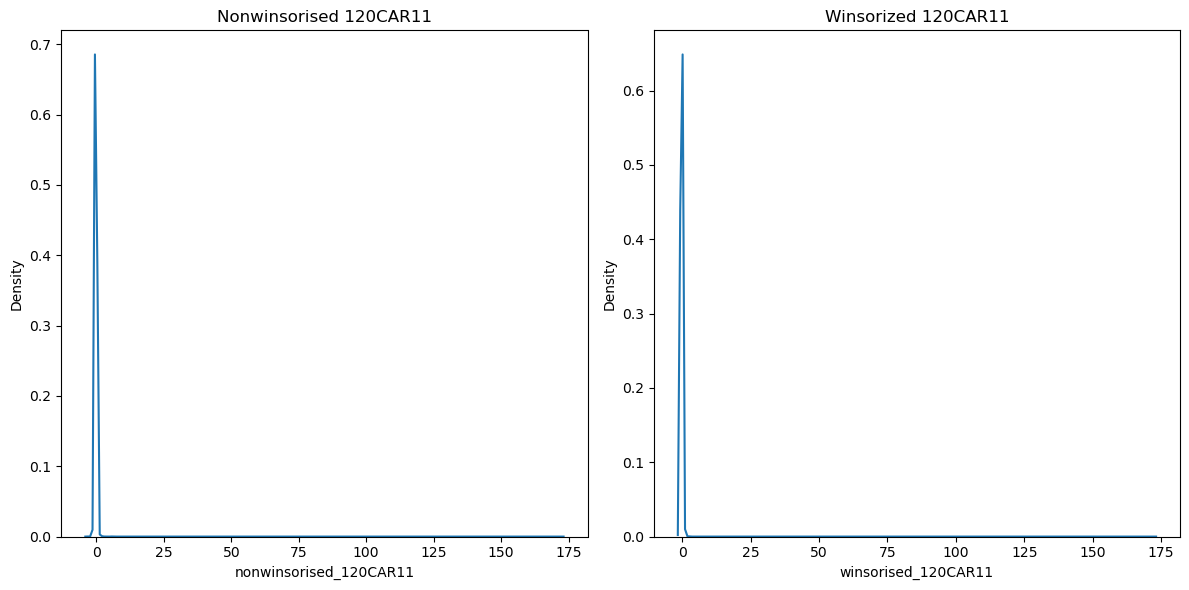

       winsorised_150CAR3  nonwinsorised_150CAR3
count         6338.000000            6338.000000
mean             0.027252               0.025402
std              2.163892               2.164132
min             -0.126168              -0.767931
25%             -0.036766              -0.036766
50%             -0.005669              -0.005669
75%              0.030158               0.030158
max            172.195933             172.195933


Top values and their count:  nonwinsorised_150CAR3
0.346465      1
0.347457      2
0.428833      1
0.432583      1
0.464732      2
0.468911      1
0.531037      1
0.567501      1
0.589509      1
172.195933    1
Name: count, dtype: int64





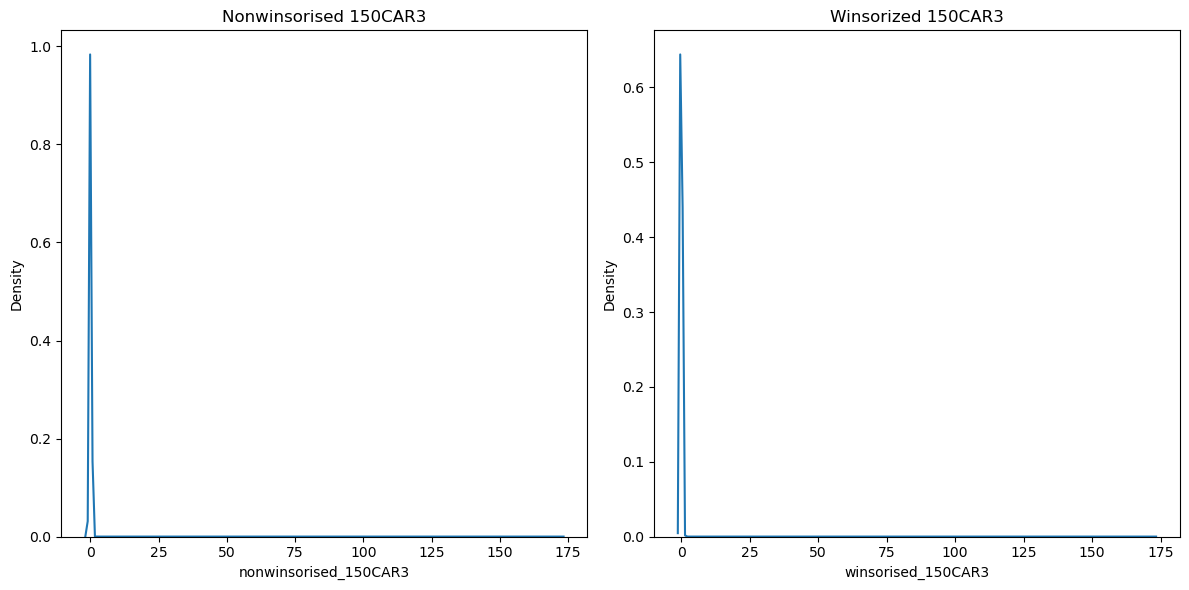

       winsorised_150CAR5  nonwinsorised_150CAR5
count         6338.000000            6338.000000
mean            -0.022387              -0.024865
std              2.164975               2.165387
min             -0.215026              -1.175801
25%             -0.096707              -0.096707
50%             -0.054227              -0.054227
75%             -0.013959              -0.013959
max            172.160930             172.160930


Top values and their count:  nonwinsorised_150CAR5
0.504308      1
0.530802      1
0.539434      2
0.598704      1
0.692687      1
0.707051      2
0.852672      1
0.931360      1
1.421520      2
172.160930    1
Name: count, dtype: int64





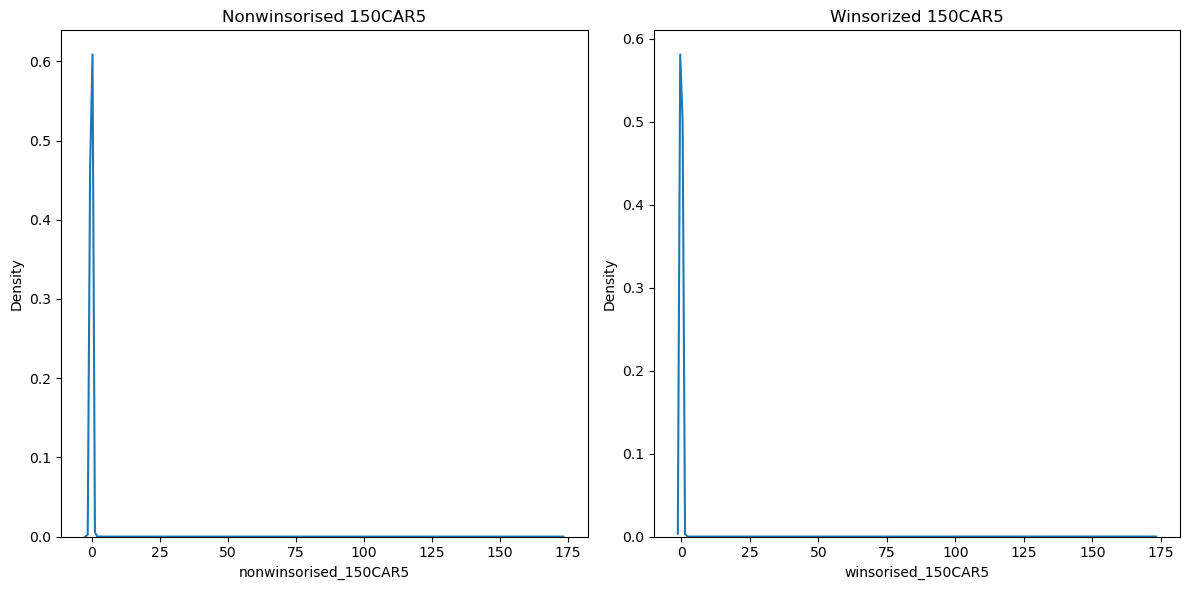

       winsorised_150CAR7  nonwinsorised_150CAR7
count         6335.000000            6335.000000
mean            -0.071138              -0.073802
std              2.166694               2.167179
min             -0.300946              -1.559946
25%             -0.158414              -0.158414
50%             -0.104045              -0.104045
75%             -0.052394              -0.052394
max            172.142176             172.142176


Top values and their count:  nonwinsorised_150CAR7
0.574693      2
0.587675      1
0.623858      1
0.627795      1
0.696607      1
0.777151      2
0.868898      2
1.340499      1
1.641332      1
172.142176    1
Name: count, dtype: int64





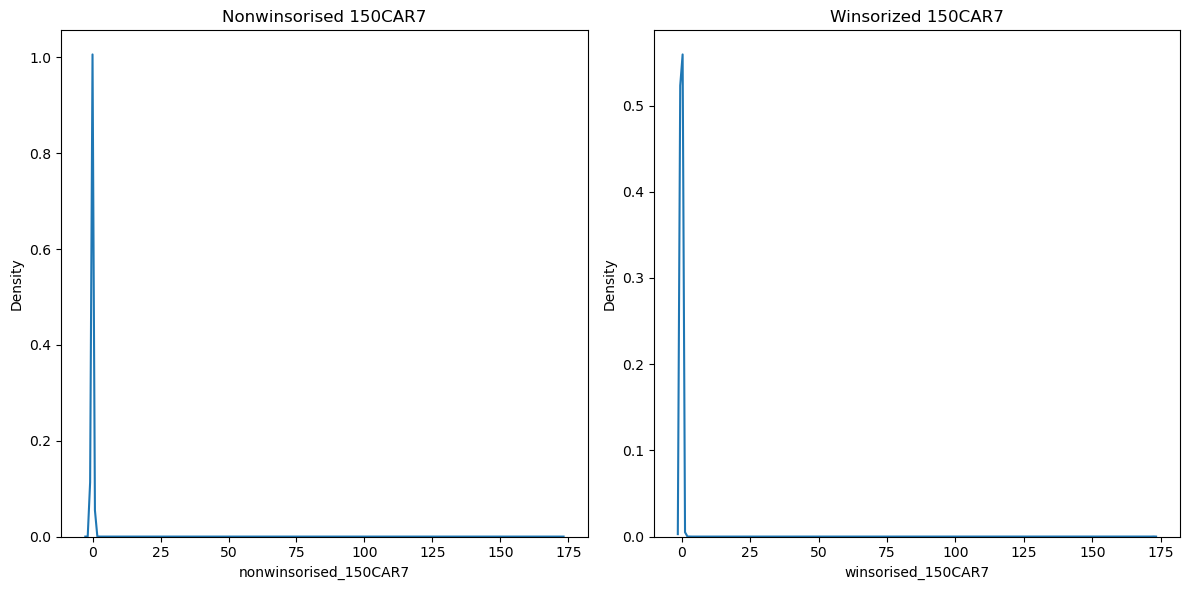

       winsorised_150CAR11  nonwinsorised_150CAR11
count          6334.000000             6334.000000
mean             -0.167755               -0.171540
std               2.169797                2.170768
min              -0.461792               -2.542102
25%              -0.275646               -0.275646
50%              -0.206477               -0.206477
75%              -0.130998               -0.130998
max             172.003660              172.003660


Top values and their count:  nonwinsorised_150CAR11
0.658685      1
0.731627      1
0.854179      2
0.975171      1
1.161769      1
1.326542      1
1.892436      2
2.023445      1
5.826507      1
172.003660    1
Name: count, dtype: int64





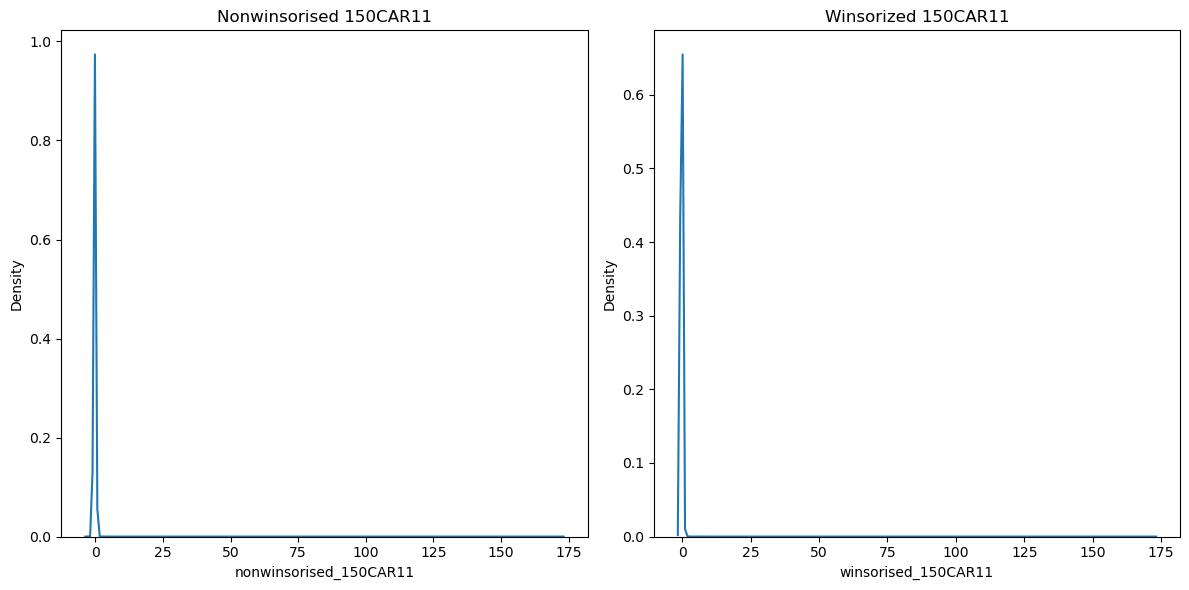

       winsorised_180CAR3  nonwinsorised_180CAR3
count         6317.000000            6317.000000
mean             0.027007               0.025123
std              2.167514               2.167745
min             -0.126761              -0.695642
25%             -0.037363              -0.037363
50%             -0.006146              -0.006146
75%              0.030300               0.030300
max            172.197025             172.197025


Top values and their count:  nonwinsorised_180CAR3
0.334384      2
0.343946      1
0.420811      1
0.434575      1
0.471489      1
0.488314      2
0.535148      1
0.593403      1
0.597871      1
172.197025    1
Name: count, dtype: int64





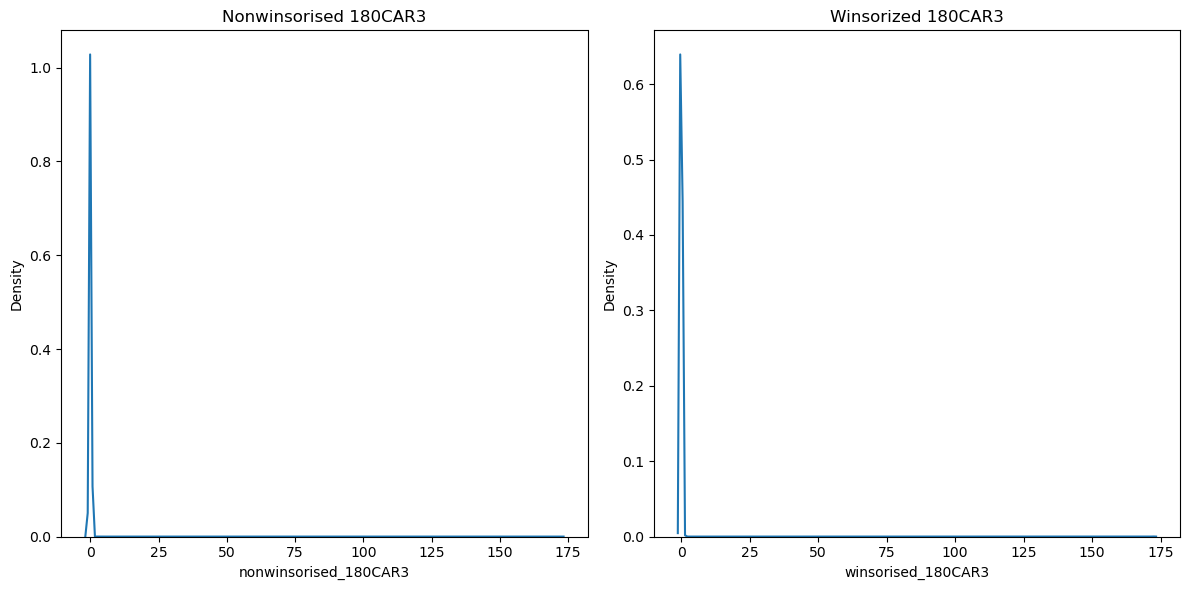

       winsorised_180CAR5  nonwinsorised_180CAR5
count         6317.000000            6317.000000
mean            -0.022796              -0.025170
std              2.168615               2.168997
min             -0.218072              -0.981951
25%             -0.097131              -0.097131
50%             -0.055340              -0.055340
75%             -0.013883              -0.013883
max            172.161940             172.161940


Top values and their count:  nonwinsorised_180CAR5
0.501630      1
0.504668      1
0.534560      1
0.673504      1
0.715774      1
0.750899      2
0.860962      1
0.917677      1
1.450691      2
172.161940    1
Name: count, dtype: int64





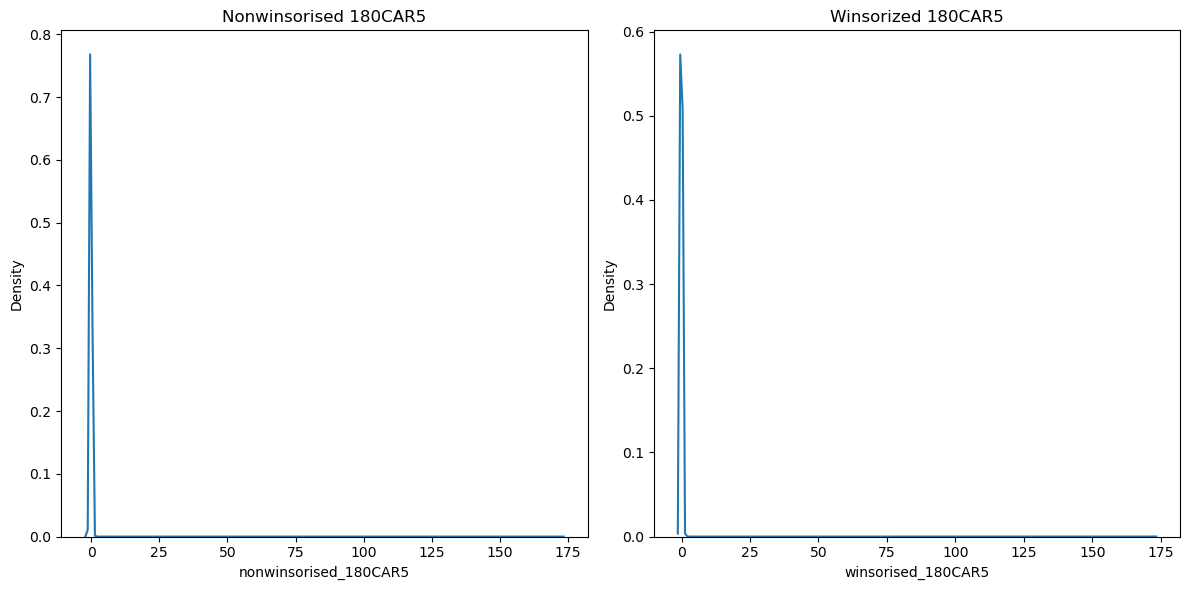

       winsorised_180CAR7  nonwinsorised_180CAR7
count         6314.000000            6314.000000
mean            -0.071206              -0.073806
std              2.170366               2.170820
min             -0.301846              -1.305520
25%             -0.158140              -0.158140
50%             -0.104064              -0.104064
75%             -0.052652              -0.052652
max            172.142544             172.142544


Top values and their count:  nonwinsorised_180CAR7
0.576599      2
0.601671      1
0.622758      1
0.659249      1
0.697917      1
0.893259      2
1.027776      2
1.344630      1
1.694966      1
172.142544    1
Name: count, dtype: int64





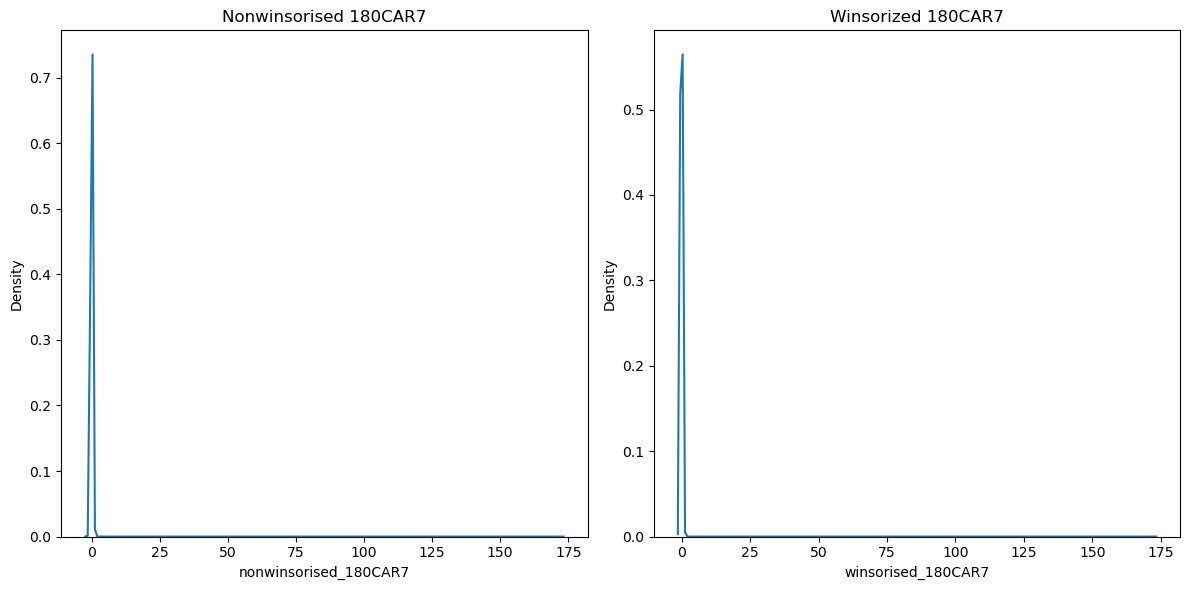

       winsorised_180CAR11  nonwinsorised_180CAR11
count          6313.000000             6313.000000
mean             -0.167366               -0.171076
std               2.173624                2.174513
min              -0.460364               -2.098553
25%              -0.275916               -0.275916
50%              -0.206914               -0.206914
75%              -0.132667               -0.132667
max             172.003280              172.003280


Top values and their count:  nonwinsorised_180CAR11
0.660261      1
0.731233      1
0.926114      2
1.020993      1
1.198482      1
1.329517      1
2.028564      1
2.373080      2
5.816717      1
172.003280    1
Name: count, dtype: int64





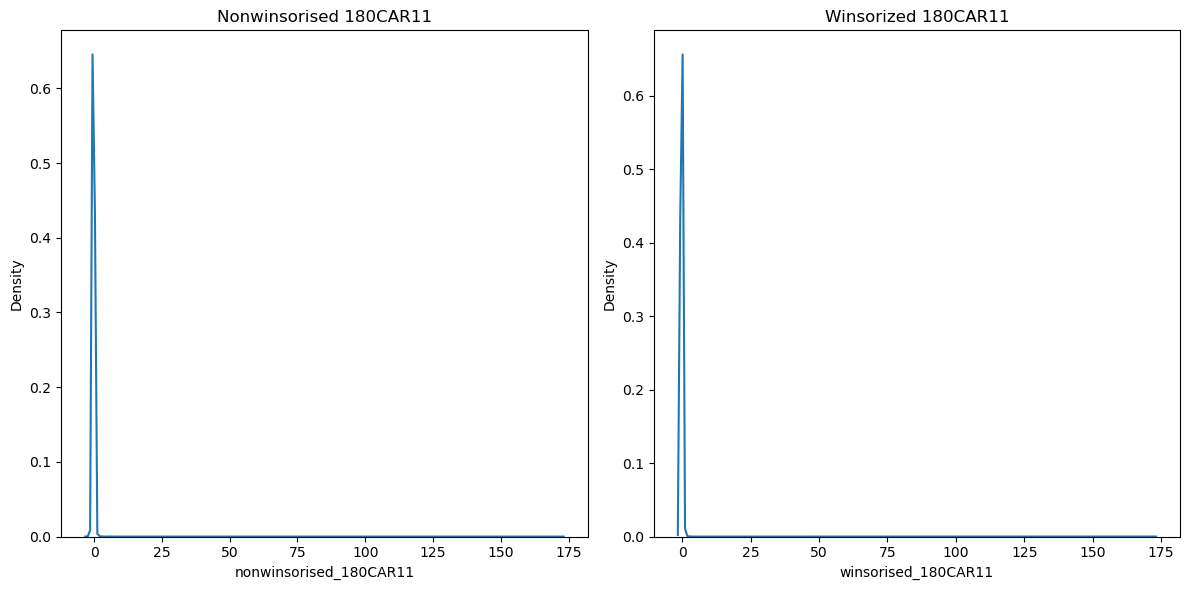

       winsorised_210CAR3  nonwinsorised_210CAR3
count         6297.000000            6297.000000
mean             0.027146               0.025220
std              2.170933               2.171196
min             -0.129367              -1.156987
25%             -0.037472              -0.037472
50%             -0.005500              -0.005500
75%              0.030595               0.030595
max            172.195045             172.195045


Top values and their count:  nonwinsorised_210CAR3
0.338693      1
0.346333      2
0.395621      1
0.432727      1
0.477187      1
0.483847      2
0.531654      1
0.592347      1
0.610097      1
172.195045    1
Name: count, dtype: int64





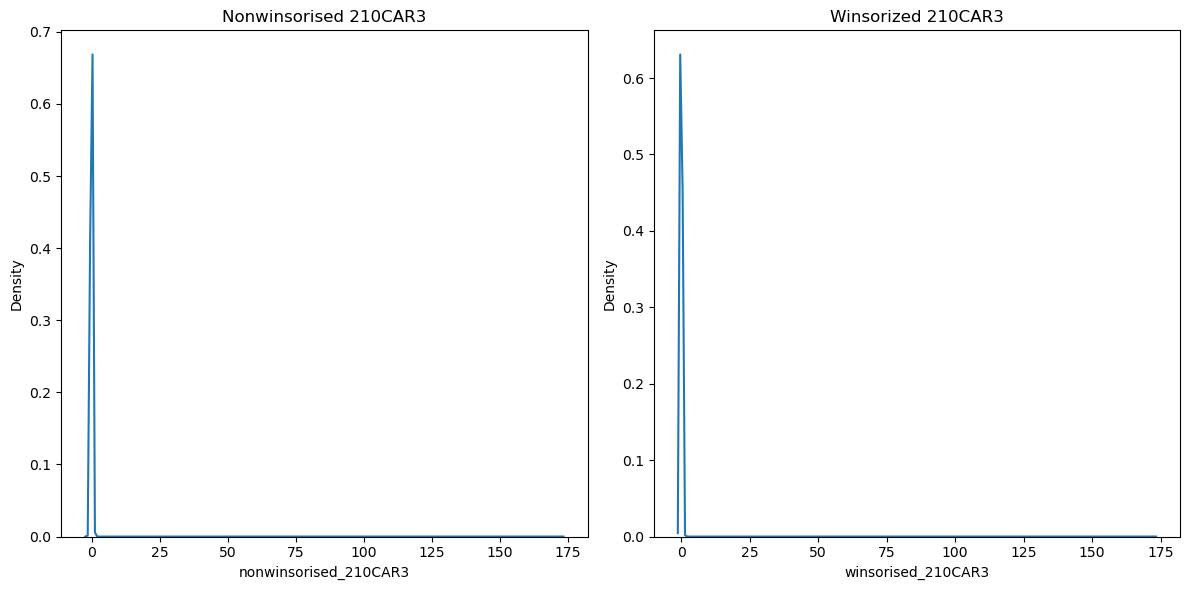

       winsorised_210CAR5  nonwinsorised_210CAR5
count         6297.000000            6297.000000
mean            -0.022706              -0.025120
std              2.172050               2.172470
min             -0.223649              -1.322327
25%             -0.096906              -0.096906
50%             -0.055148              -0.055148
75%             -0.014042              -0.014042
max            172.160364             172.160364


Top values and their count:  nonwinsorised_210CAR5
0.508274      1
0.532465      2
0.532976      1
0.704300      1
0.737757      1
0.742416      2
0.861614      1
0.885041      1
1.449875      2
172.160364    1
Name: count, dtype: int64





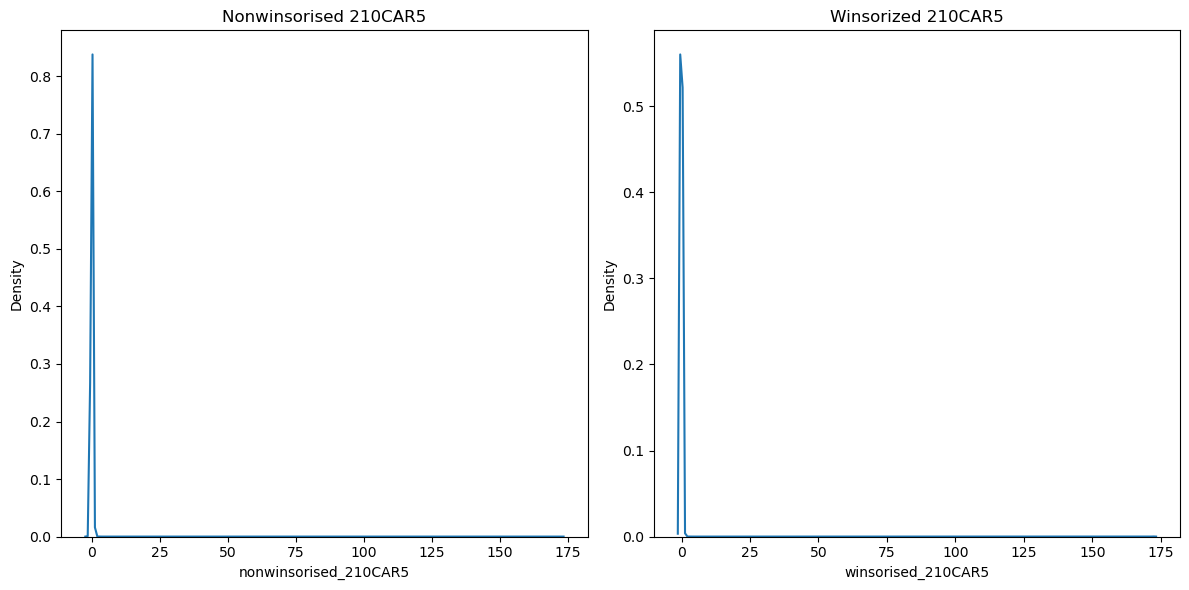

       winsorised_210CAR7  nonwinsorised_210CAR7
count         6294.000000            6294.000000
mean            -0.071247              -0.074072
std              2.173812               2.174344
min             -0.302656              -1.660867
25%             -0.158965              -0.158965
50%             -0.104076              -0.104076
75%             -0.053838              -0.053838
max            172.142646             172.142646


Top values and their count:  nonwinsorised_210CAR7
0.575180      2
0.576644      1
0.623038      1
0.694031      1
0.694186      1
0.900406      2
1.076781      2
1.342183      1
1.707762      1
172.142646    1
Name: count, dtype: int64





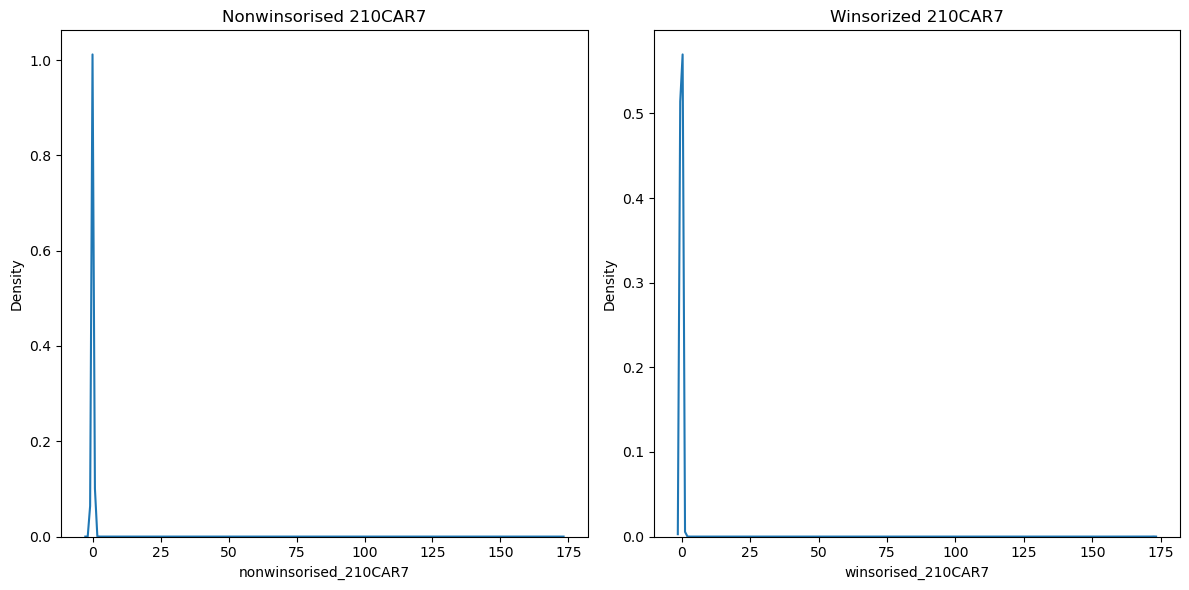

       winsorised_210CAR11  nonwinsorised_210CAR11
count          6293.000000             6293.000000
mean             -0.167276               -0.171022
std               2.177076                2.177947
min              -0.461080               -1.685227
25%              -0.275399               -0.275399
50%              -0.207404               -0.207404
75%              -0.132147               -0.132147
max             172.003609              172.003609


Top values and their count:  nonwinsorised_210CAR11
0.657770      1
0.731207      1
0.900506      2
1.145340      1
1.197564      1
1.249906      1
2.025149      1
2.483369      2
5.814373      1
172.003609    1
Name: count, dtype: int64





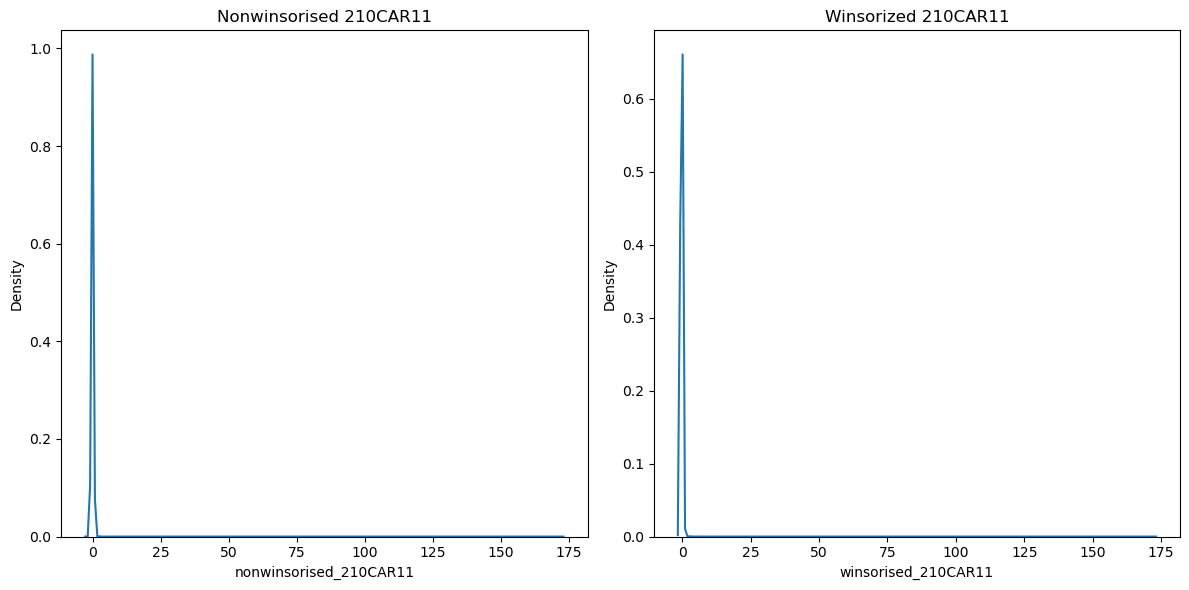

In [10]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    print("\n\nTop values and their count: ", (sample[f"nonwinsorised_{variable}"].value_counts().sort_index().tail(n=10)))
    print("\n\n")
    
    # Graphs
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

for car in carCol:
    psmSampleIndep[car] = winsorize_output(psmSampleIndep, car, [0.01, 0.01])

In [11]:
# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "PC1_FactorScore_Standardised", "ln_dirage", "ln_directorships"
# ]
# filter_datas = []
# CARs = [120, 150, 180, 210]
# for i,CAR in enumerate(CARs):
#     frame = pd. read_pickle(rf"{filtering_folder_path}\Insufficient Data for {CAR}CAR.pkl").rename({"AsOnDate":"Date"}, axis = 1)
#     filter_datas.append(frame)

# carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
#           "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
#           "180CAR3", "180CAR5", "180CAR7", "180CAR11",
#           "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

# print("N for each CAR, no subsampling, dropping for na in control vars + car")

# event_days = [3, 5, 7, 11]

# for i,CAR in enumerate(CARs):
#     frame = psmSampleIndep.merge(filter_datas[i], left_on = ["CompanyName", "Appointment Date"], right_on = ["CompanyName", "Date"], how = "left")
#     for days in event_days:
#         car = f"{CAR}CAR{days}"
#         print(f"{car} N = ", frame.dropna(subset = [car] + controlVars)["na_trading_days"].mean() )

# frame_filtered = frame.dropna(subset=[car] + controlVars)
# frame_filtered["index"] = frame_filtered.index
# frame_filtered.plot(kind="scatter", x="index", y="na_trading_days")

In [12]:
# dirFirm2 = dirFirm.copy()
# psmSampleIndep2 = psmSampleIndep.copy()

# listCol = [
#     "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
#     "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
#     "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
#     "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
#     "OtherFirstYearPCodeIndepExcl","OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
#     "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
# ]

# dirFirm2 = dirFirm2.drop(listCol, axis = 1)
# psmSampleIndep2 = psmSampleIndep2.drop(listCol, axis = 1)


# dirFirm2.to_csv("Main_Firm_PSM Ready_no filter v040425.csv")
# psmSampleIndep2.to_csv("Main_Firm_PSM Ready_filter-Indep_gov_fin v040425.csv")


# # # psmSampleAll --> 2101 rows 
# # psmSampleIndep --> 1561 rows 

## PSM --> RookieAppoints as Treatment, NonRookieAppoints as Control

In [13]:
def LogitReg(sample, endog_var, exog_var):
    
    # Logit Regression
    endog = sample[endog_var]
    exog = sample[exog_var]
    
    scaler = StandardScaler()
    exog_standardised = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns)

    exog_standardised = sm.add_constant(exog_standardised)
    
    log_reg = sm.Logit(endog, exog_standardised).fit()

    propensityScores = log_reg.predict(exog_standardised)
    
    return propensityScores

In [14]:
def MeanDiffTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    if depVar != None:
        dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
        colsAdd = []
        for i in range(-1, 4):
            if i != 0:
                colsAdd.append(f"AsOnYear_T+{i}")
                colsAdd.append(f"{depVar}T+{i}")
                if i>0 :
                    colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
        newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "float")
        sample = pd.concat([sample, newFrame], axis = 1)
        sample = sample.copy()
        
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
                                                              right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
        for i in range(1, 4):
            if i != 0:
                sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
        sample = sample.copy()
    
    group1 = sample.loc[ sample[endog_var] == 1].copy()
    group2 = sample.loc[ sample[endog_var] == 0].copy()
    
    t_stat, p_value = stats.ttest_ind(group1[car], group2[car], equal_var=False)  # Welch’s t-test (default)

    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Treated Mean:", group1[car].mean(), " Control Mean:", group2[car].mean(), " Diff:", group1[car].mean() - group2[car].mean())
    print("Treated Median:", group1[car].median(), " Control Median:", group2[car].median(), " Diff:", group1[car].median() - group2[car].median())
    print("Treated N:", len(group1[car]), "; Control N:", len(group2[car]))
    print("[treated unique = ", len(group1.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]",\
          "[control unique = ", len(group2.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]"
         )
    print("\n")

    # -----------------------------------------------------------------------------------------------------------------
    
    if exog_var != None:
        print("━"*120)
        print(f'{"Matching Variable":<40} {"Treatment":<20} {"Control":<20} {"SMD":<20}')
        print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
        print("-"*120)

        for var in exog_var:
            treatMean = group1[var].mean()
            controlMean = group2[var].mean()
            # p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
            smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
            print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {smd:<20.4f}')
    
        print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    if depVar != None:
        print(depVar, " across years:\n")
        for i in range(1,4):
            sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
        group1 = sample.loc[ sample[endog_var] == 1].copy()
        group2 = sample.loc[ sample[endog_var] == 0].copy()

        print("━"*150, "\n")
        print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
        print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
        print("─"*150, "\n")
    
        for i in range(1,4):
            t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
            treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
            controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
            diffMean = treatedMean - controlMean
    
            treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
            controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
            diffMedian = treatedMedian - controlMedian
    
            print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
            label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            label2 = "Control N: " + str(len(group2[depVar+f'(T+{i}) - (T-1)']))
            
            print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
            print("-"*150, "\n")
            
        print("━"*150, "\n")

    return

In [15]:
def OneSampleTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    # if depVar != None:
    #     dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
    #     colsAdd = []
    #     for i in range(-1, 4):
    #         if i != 0:
    #             colsAdd.append(f"AsOnYear_T+{i}")
    #             colsAdd.append(f"{depVar}T+{i}")
    #             if i>0 :
    #                 colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
    #     newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "int")
    #     sample = pd.concat([sample, newFrame], axis = 1)
    #     sample = sample.copy()
        
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
    #                                                           right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
    #     for i in range(1, 4):
    #         if i != 0:
    #             sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
    #     sample = sample.copy()
    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    group1 = sample.copy()
    
    t_stat, p_value = stats.ttest_1samp(group1[car], 0)  # Welch’s t-test (default)
    
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Mean:", group1[car].mean())
    print("Median:", group1[car].median())
    print("N:", len(group1[car]))

    print("\n")

    # -----------------------------------------------------------------------------------------------------------------




    # if exog_var != None:
    #     print("━"*120)
    #     print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
    #     print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
    #     print("-"*120)

    #     for var in exog_var:
    #         treatMean = group1[var].mean()
    #         controlMean = group2[var].mean()
    #         p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
    #         print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
    #     print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    # if depVar != None:
    #     print(depVar, " across years:\n")
    #     for i in range(1,4):
    #         sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
    #     group1 = sample.loc[ sample[endog_var] == 1].copy()
    #     group2 = sample.loc[ sample[endog_var] == 0].copy()

    #     print("━"*150, "\n")
    #     print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
    #     print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
    #     print("─"*150, "\n")
    
    #     for i in range(1,4):
    #         t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
    #         treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
    #         controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
    #         diffMean = treatedMean - controlMean
    
    #         treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
    #         controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
    #         diffMedian = treatedMedian - controlMedian
    
    #         print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
    #         label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
    #         label2 = "Control N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            
    #         print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
    #         print("-"*150, "\n")
            
    #print("━"*150, "\n")

    return

In [16]:
def PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    treated = sample.loc[ sample[endog_var] == 1].copy()
    control = sample.loc[ sample[endog_var] == 0].copy()

    # Nearest Neighbours
    nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean")
    nn.fit(control[["propensityScore"]])

    distances, indices = nn.kneighbors(treated[["propensityScore"]])
    
    matchedControl = control.iloc[indices.flatten()].copy()
    
    matched = pd.concat([treated, matchedControl])
    matched.reset_index(drop=True, inplace=True)

    MeanDiffTtest(matched, endog_var, exog_var, car, depVar, dirFirm)

    return

In [17]:
# Func PSM non replacement
def PsmNonReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    # Separate treated and control groups
    treated = sample[sample[endog_var] == 1].copy()
    control = sample[sample[endog_var] == 0].copy()
    
    # Compute pairwise distances (absolute difference in propensity scores)
    dist_matrix = cdist(treated[['propensityScore']], control[['propensityScore']], metric='euclidean')
    
    # Match without replacement
    treated_indices = []
    matched_indices = []
    used_control_indices = set()
    
    for i in range(len(treated)):
        if len(used_control_indices) >= len(control):  # Stop if no controls left
            print("Warning: Not enough control units to match all treated units.")
            break
        
        # Get nearest control unit index that hasn't been used
        match_idx = np.argmin(dist_matrix[i])
        
        while match_idx in used_control_indices:  # Ensure it's not already matched
            dist_matrix[i, match_idx] = np.inf  # Temporarily set distance to infinity

            if np.all(dist_matrix[i] == np.inf):  # If all controls are exhausted
                print(f"No available control for treated unit {i}, skipping.")
                match_idx = None
                break
            
            match_idx = np.argmin(dist_matrix[i])
        
        used_control_indices.add(match_idx)
        matched_indices.append(match_idx)
        treated_indices.append(i)
    
    # Retrieve matched units
    matched_control = control.iloc[matched_indices].copy()
    matched_treated = treated.iloc[treated_indices].copy()
    
    # Combine matched treated and control units
    matched_data = pd.concat([matched_treated.reset_index(drop=True), matched_control.reset_index(drop=True)])
    
    # Reset index
    matched_data.reset_index(drop=True, inplace=True)


    # Mean difference and T Test
    MeanDiffTtest(matched_data, endog_var, exog_var, car, depVar, dirFirm)

    return
    


In [18]:
def prep_sample(sample, car, controlVars, yearDummy = 0, industryDummy = 0) -> tuple[pd.DataFrame, list[str]]:
    
    sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)

    if yearDummy == 1:
        yearDummies = pd.get_dummies( sample["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = yearDummies.sum().loc[ yearDummies.sum() == 1 ].index.values
        yearDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, yearDummies], axis = 1)
    else:
        yearDummies = pd.DataFrame()
    
    if industryDummy == 1:
        industryDummies = pd.get_dummies( sample["NIC_1digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = industryDummies.sum().loc[ industryDummies.sum() == 1 ].index.values
        industryDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, industryDummies], axis = 1)
    else:
        industryDummies = pd.DataFrame()

    exog_var = controlVars + yearDummies.columns.to_list() + industryDummies.columns.to_list()

    # checking for multicollinearity
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    from statsmodels.tools.tools import add_constant
    exog_with_const = add_constant(sample[exog_var])
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = exog_with_const.columns
    vif_data["VIF"] = [variance_inflation_factor(exog_with_const.values, i)
                       for i in range(exog_with_const.shape[1])]
    highCollinearity = [x for x in 
                    vif_data.loc[ vif_data["VIF"] > 10 ]["feature"].values
                    if x!="const"]
    exog_var = [x for x in exog_var if x not in highCollinearity]    
    
    return sample, exog_var

# PSM on PCA output + other controls

In [19]:
controlVars = ["PercentWomenDir", "PercentBusyDir",
               "LnBoardSize", "PercentIndep",
               "Promoters_percent", "NonpromoterInstitutions_percent",
               "ln_marcap", "ln_rdtoassets", "Debt to equity ratio"]

# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "Skilllist_FactorScore", "ln_dirage", "ln_directorships"
# ]

#PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm)

# No Higher level Filtration

## Version 0: No filtration

## No fixed effects

### PSM with replacement

In [20]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.438556
         Iterations 6


120CAR3 :


T Statistic: -0.5878861936462685  P Value: 0.5566830963387892
Treated Mean: -0.0010245265053586792  Control Mean: 0.0006874476404900793  Diff: -0.0017119741458487584
Treated Median: -0.005755476308963857  Control Median: -0.0044044576326546445  Diff: -0.0013510186763092125
Treated N: 894 ; Control N: 894
[treated unique =  894 ] [control unique =  623 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 894              N = 894             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1784               0.1739               0.0407        

## Using Year fixed effects

### PSM with replacement

In [21]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.431846
         Iterations 7


120CAR3 :


T Statistic: -1.131730306054721  P Value: 0.2578997686583707
Treated Mean: -0.001060093387720659  Control Mean: 0.0022788862614719534  Diff: -0.0033389796491926126
Treated Median: -0.005755476308963857  Control Median: -0.0043073711092576975  Diff: -0.0014481051997061595
Treated N: 894 ; Control N: 894
[treated unique =  894 ] [control unique =  614 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 894              N = 894             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1784               0.1806               -0.0200         

## Using Year + Industry fixed effects

### PSM with replacement

In [22]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.430578
         Iterations 7


120CAR3 :


T Statistic: -1.4181433496716056  P Value: 0.15632337705163782
Treated Mean: -0.0010624972421183234  Control Mean: 0.0031181301751240257  Diff: -0.004180627417242349
Treated Median: -0.005755476308963857  Control Median: -0.0031563647300562117  Diff: -0.002599111578907645
Treated N: 894 ; Control N: 894
[treated unique =  894 ] [control unique =  609 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 894              N = 894             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1784               0.1769               0.0139         

In [23]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [24]:
psmSampleIndep1 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [25]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.433780
         Iterations 7


120CAR3 :


T Statistic: -0.9563500226936131  P Value: 0.33925454825730883
Treated Mean: -1.8923532587006724e-05  Control Mean: 0.00478116593242401  Diff: -0.004800089465011016
Treated Median: -0.007396892767032988  Control Median: -0.0003698493993335786  Diff: -0.007027043367699409
Treated N: 325 ; Control N: 325
[treated unique =  325 ] [control unique =  226 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 325              N = 325             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1864               0.1864               0.0003          

## Using Year fixed effects

### PSM with replacement

In [26]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.421344
         Iterations 7


120CAR3 :


T Statistic: -0.05845931131184624  P Value: 0.9534008388034398
Treated Mean: 0.0003208275969885341  Control Mean: 0.0006396650052224408  Diff: -0.00031883740823390673
Treated Median: -0.007396892767032988  Control Median: -0.004173075984744437  Diff: -0.003223816782288551
Treated N: 325 ; Control N: 325
[treated unique =  325 ] [control unique =  220 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 325              N = 325             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1864               0.1836               0.0262         

## Using Year + Industry fixed effects

### PSM with replacement

In [27]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.418825
         Iterations 7


120CAR3 :


T Statistic: -1.7521768102785176  P Value: 0.08021769262363204
Treated Mean: 0.0003889331569165109  Control Mean: 0.009997350191894681  Diff: -0.00960841703497817
Treated Median: -0.007396892767032988  Control Median: -0.0014154465304976743  Diff: -0.0059814462365353135
Treated N: 325 ; Control N: 325
[treated unique =  325 ] [control unique =  214 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 325              N = 325             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1864               0.1964               -0.0879          

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [28]:
psmSampleIndep2 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [29]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.425248
         Iterations 6


120CAR3 :


T Statistic: -0.04586933215206327  P Value: 0.9634238538698322
Treated Mean: 2.5194411840819094e-05  Control Mean: 0.00019248217080401764  Diff: -0.00016728775896319853
Treated Median: -0.002939192464582435  Control Median: -0.0033637275504258962  Diff: 0.000424535085843461
Treated N: 486 ; Control N: 486
[treated unique =  486 ] [control unique =  334 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 486              N = 486             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1760               0.1756               0.0037       

## Using Year fixed effects

### PSM with replacement

In [30]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.418225
         Iterations 7


120CAR3 :


T Statistic: 0.8685284054914068  P Value: 0.385320196362959
Treated Mean: -2.4177564593998607e-05  Control Mean: -0.003194424351138728  Diff: 0.0031702467865447293
Treated Median: -0.002939192464582435  Control Median: -0.007506385512957455  Diff: 0.00456719304837502
Treated N: 486 ; Control N: 486
[treated unique =  486 ] [control unique =  336 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 486              N = 486             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1760               0.1724               0.0347              

## Using Year + Industry fixed effects

### PSM with replacement

In [31]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.416939
         Iterations 7


120CAR3 :


T Statistic: 0.7424289358686726  P Value: 0.458007779366003
Treated Mean: 2.5194411840819094e-05  Control Mean: -0.002662573588103286  Diff: 0.0026877679999441047
Treated Median: -0.002939192464582435  Control Median: -0.0022808185701514855  Diff: -0.0006583738944309497
Treated N: 486 ; Control N: 486
[treated unique =  486 ] [control unique =  341 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 486              N = 486             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1760               0.1811               -0.0463          

In [32]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Higher level Filteration: DUPLICATED DIRECTORS REMOVED

## Version 0: No filtration

In [33]:
# psmSampleIndep0 = psmSampleIndep.copy()

# yearDummies0 = pd.get_dummies( psmSampleIndep0["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearDummies0 = pd.concat([psmSampleIndep0, yearDummies0], axis = 1)

# industryDummies0 = pd.get_dummies( psmSampleIndep0["NIC_2digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearIndustryDummies0 = pd.concat([psmSampleIndepWithYearDummies0, industryDummies0], axis = 1)

# depVar = None

In [34]:
duplicated = psmSampleIndep.duplicated(subset = ["Symbol", "Appointment Date"], keep = False).to_frame("val")
filtered_index = duplicated.loc[duplicated["val"] == False].index
psmSampleIndep_filtered = psmSampleIndep.loc[filtered_index].copy()

## No fixed effects

### PSM with replacement

In [35]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.436103
         Iterations 6


120CAR3 :


T Statistic: -0.32543533130125707  P Value: 0.7449040086080478
Treated Mean: -0.0008837333273259904  Control Mean: 0.00024502466149772985  Diff: -0.0011287579888237202
Treated Median: -0.006909433073763974  Control Median: -0.0044044576326546445  Diff: -0.002504975441109329
Treated N: 651 ; Control N: 651
[treated unique =  651 ] [control unique =  469 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 651              N = 651             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1777               0.1826               -0.0454      

## Using Year fixed effects

### PSM with replacement

In [36]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.427309
         Iterations 7


120CAR3 :


T Statistic: -1.0538045303656554  P Value: 0.29216916920106606
Treated Mean: -0.0011290773767514697  Control Mean: 0.002396121344756905  Diff: -0.003525198721508375
Treated Median: -0.006909433073763974  Control Median: -0.005228395890047456  Diff: -0.0016810371837165175
Treated N: 651 ; Control N: 651
[treated unique =  651 ] [control unique =  466 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 651              N = 651             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1777               0.1740               0.0339          

## Using Year + Industry fixed effects

### PSM with replacement

In [37]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.426632
         Iterations 7


120CAR3 :


T Statistic: -0.07825889455818673  P Value: 0.9376341908760528
Treated Mean: -0.0012074625827024693  Control Mean: -0.0009445837324061528  Diff: -0.00026287885029631646
Treated Median: -0.006909433073763974  Control Median: -0.0029423394330672092  Diff: -0.003967093640696764
Treated N: 651 ; Control N: 651
[treated unique =  651 ] [control unique =  471 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 651              N = 651             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1777               0.1809               -0.0291     

In [38]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [39]:
psmSampleIndep1 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [40]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.437416
         Iterations 7


120CAR3 :


T Statistic: -0.17566377815743434  P Value: 0.8606328176594632
Treated Mean: -0.00026604121835743024  Control Mean: 0.0008518493149475774  Diff: -0.0011178905333050076
Treated Median: -0.007396892767032988  Control Median: -0.006149438853624706  Diff: -0.001247453913408282
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  170 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1867               -0.0158       

## Using Year fixed effects

### PSM with replacement

In [41]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.421023
         Iterations 7


120CAR3 :


T Statistic: 0.5718850744116594  P Value: 0.5676725097690314
Treated Mean: -0.0006882126127134327  Control Mean: -0.004053120749566365  Diff: 0.0033649081368529324
Treated Median: -0.007396892767032988  Control Median: -0.012739033282561193  Diff: 0.005342140515528206
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  178 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1817               0.0289             

## Using Year + Industry fixed effects

### PSM with replacement

In [42]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.417742
         Iterations 7


120CAR3 :


T Statistic: -0.2625663102963027  P Value: 0.7929996358180467
Treated Mean: -0.0003072847185479912  Control Mean: 0.0012676894903436917  Diff: -0.0015749742088916828
Treated Median: -0.007396892767032988  Control Median: -0.0032354797210703834  Diff: -0.0041614130459626045
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  172 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1948               -0.0854       

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [43]:
psmSampleIndep2 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [44]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.420469
         Iterations 6


120CAR3 :


T Statistic: -0.7139572966406124  P Value: 0.475491572741502
Treated Mean: 0.0006556884727994586  Control Mean: 0.003792977699868731  Diff: -0.0031372892270692724
Treated Median: -0.0058394670844112845  Control Median: -0.00235239284868162  Diff: -0.0034870742357296647
Treated N: 351 ; Control N: 351
[treated unique =  351 ] [control unique =  254 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 351              N = 351             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1738               0.1790               -0.0502           

## Using Year fixed effects

### PSM with replacement

In [45]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.411122
         Iterations 7


120CAR3 :


T Statistic: 1.0228523170115926  P Value: 0.30673166029074594
Treated Mean: 0.0002408710736166334  Control Mean: -0.0040755743882009395  Diff: 0.004316445461817573
Treated Median: -0.0058394670844112845  Control Median: -0.008760336168096947  Diff: 0.002920869083685662
Treated N: 351 ; Control N: 351
[treated unique =  351 ] [control unique =  260 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 351              N = 351             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1738               0.1764               -0.0247           

## Using Year + Industry fixed effects

### PSM with replacement

In [46]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.410795
         Iterations 7


120CAR3 :


T Statistic: -0.6549242703809702  P Value: 0.5127327473945109
Treated Mean: 0.0002408710736166334  Control Mean: 0.0029671509398390998  Diff: -0.0027262798662224664
Treated Median: -0.0058394670844112845  Control Median: -0.002209244291621351  Diff: -0.0036302227927899333
Treated N: 351 ; Control N: 351
[treated unique =  351 ] [control unique =  248 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 351              N = 351             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1738               0.1712               0.0244         

In [47]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 3: Non family firms promoterholding25==0 & hasfamilychairmanandceo==0

In [48]:
psmSampleIndep3 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==0) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [49]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.519080
         Iterations 6


120CAR3 :


T Statistic: -0.6542477457733116  P Value: 0.5148355631451759
Treated Mean: 0.0048991180789973825  Control Mean: 0.014559264205277317  Diff: -0.009660146126279934
Treated Median: 0.00268504955138699  Control Median: 0.014223005865437531  Diff: -0.011537956314050541
Treated N: 42 ; Control N: 42
[treated unique =  42 ] [control unique =  31 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 42               N = 42              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1830               0.1846               -0.0118             
Perce

## Using Year fixed effects

### PSM with replacement

In [50]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.479093
         Iterations 6


120CAR3 :


T Statistic: -0.2708604798402727  P Value: 0.7873112543918008
Treated Mean: 0.0048991180789973825  Control Mean: 0.008501944215685302  Diff: -0.0036028261366879196
Treated Median: 0.00268504955138699  Control Median: 0.01022128930352114  Diff: -0.00753623975213415
Treated N: 42 ; Control N: 42
[treated unique =  42 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 42               N = 42              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1830               0.1575               0.1973              
Percen

## Using Year + Industry fixed effects

### PSM with replacement

In [51]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.477366
         Iterations 6


120CAR3 :


T Statistic: -0.3142093136319335  P Value: 0.754278116833849
Treated Mean: 0.0048991180789973825  Control Mean: 0.009162664888829108  Diff: -0.004263546809831726
Treated Median: 0.00268504955138699  Control Median: 0.00510344251023934  Diff: -0.00241839295885235
Treated N: 42 ; Control N: 42
[treated unique =  42 ] [control unique =  27 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 42               N = 42              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1830               0.1543               0.2135              
PercentB

In [52]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 4: Rookie in Family firms vs Rookie in non family firms, family firms => promoterholding25 == 1, HasFamilyChairmanAndCEO == 1; non family ==0 for both

IMPORTANT NOTE!!!!!!!!!!!!
promoters_percent resulted in singular matrices and therefore has been removed from the covariates

In [53]:
filtered = psmSampleIndep_filtered.loc[ psmSampleIndep_filtered["IsRookieIndep"] == 1].copy()

filtered["familyfirm_dummy"] = np.where((filtered["promoterholding25"]==1) & (filtered["HasFamilyChairmanAndCEO"]==1),
                                                1,0)
filtered["nonfamilyfirm_dummy"] = np.where((filtered["promoterholding25"]==0) & (filtered["HasFamilyChairmanAndCEO"]==0),
                                                1,0)
                                                
psmSampleIndep3 = filtered.loc[ ((filtered["familyfirm_dummy"] == 1) | 
                                 (filtered["nonfamilyfirm_dummy"] == 1))].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [54]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 0, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.393398
         Iterations 7


120CAR3 :


T Statistic: -3.4779975061008157  P Value: 0.0005525432134233343
Treated Mean: -0.001193995678711414  Control Mean: 0.021491256286050853  Diff: -0.022685251964762267
Treated Median: -0.007396892767032988  Control Median: 0.03137350040177467  Diff: -0.038770393168807656
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  29 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1905               -0.0483            

## Using Year fixed effects

### PSM with replacement

In [55]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.368362
         Iterations 7


120CAR3 :


T Statistic: -2.1904457106590174  P Value: 0.028976278841653266
Treated Mean: -0.001193995678711414  Control Mean: 0.012065764891850971  Diff: -0.013259760570562384
Treated Median: -0.007396892767032988  Control Median: 0.03137350040177467  Diff: -0.038770393168807656
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  30 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1439               0.3859              

## Using Year + Industry fixed effects

### PSM with replacement

In [56]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 1)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.361973
         Iterations 7


120CAR3 :


T Statistic: -1.8296843371207399  P Value: 0.06794299328917043
Treated Mean: -0.001193995678711414  Control Mean: 0.01100138873995965  Diff: -0.012195384418671063
Treated Median: -0.007396892767032988  Control Median: 0.015635916661793772  Diff: -0.02303280942882676
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  29 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1852               -0.0021             
P

In [57]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

In [58]:
# endog_var = "familyfirm_dummy"
# endog = sample[[endog_var]]
# exog = sample[[x for x in exog_var if x != "Promoters_percent"]]
# exog = sm.add_constant(exog)

# log_reg = sm.Logit(endog, exog).fit()

# propensityScores = log_reg.predict(exog)

# sample[["Promoters_percent", "familyfirm_dummy"]]

# pd.crosstab(sample["Promoters_percent"], sample["familyfirm_dummy"])

# exog_var